# Agglomeration

##  Get agglomerations

In [1]:
# import osmnx as ox
import pandas as pd
import geopandas as gpd
import networkx as nx
import numpy as np
import warnings
import sys
import os
warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')

# local crs
local_crs = 32636

In [2]:
from popframe.models.region import Region

region_model = Region.from_pickle('data/Ленинградская область.pickle')
towns_gdf = gpd.read_file('data/spatial_inequality_gdf.geojson')


In [3]:
towns_gdf = towns_gdf.to_crs(32636)
towns_gdf.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
towns_gdf = towns_gdf.reset_index().rename(columns={'index': 'id'})
towns_gdf

,id,provision,basic,additional,comfort,soc_workers_dev,soc_workers_soc,soc_workers_bas,soc_old_dev,soc_old_soc,...,soc_parents_dev,soc_parents_soc,soc_parents_bas,is_anchor_settlement,name,population,parent_id,parent_name,territory_id,geometry
0,0,0.443333,0.33,0.6,0.4,0,0.031308,0.615232,0.194644,0.079995,...,0.316945,0.031308,0.119223,False,деревня Болото,10.0,6.0,Борское сельское поселение,207,POINT (543142.339 6580637.744)
1,1,0.590000,0.67,0.7,0.4,0,0.031308,0.615232,0.194644,0.079995,...,0.316945,0.031308,0.119223,False,деревня Большой Остров,68.0,6.0,Борское сельское поселение,208,POINT (544532.929 6593228.214)
2,2,0.590000,0.67,0.7,0.4,0,0.031308,0.615232,0.194644,0.079995,...,0.316945,0.031308,0.119223,False,деревня Бор,1734.0,6.0,Борское сельское поселение,209,POINT (544895.402 6593052.876)
3,3,0.543333,0.53,0.7,0.4,0,0.031308,0.615232,0.194644,0.079995,...,0.316945,0.031308,0.119223,False,деревня Бороватое,10.0,6.0,Борское сельское поселение,210,POINT (543993.111 6589582.121)
4,4,0.333333,0.20,0.6,0.2,0,0.031308,0.615232,0.194644,0.079995,...,0.316945,0.031308,0.119223,False,деревня Бочево,10.0,6.0,Борское сельское поселение,211,POINT (538540.11 6576793.684)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,0.266667,0.20,0.4,0.2,0,0.098783,0.744398,0.271781,0.097485,...,0.190276,0.098783,0.338247,False,деревня Апраксин Бор,313.0,205.0,Трубникоборское сельское поселение,3133,POINT (399059.742 6560341.471)
2927,2927,0.356667,0.27,0.4,0.4,0,0.098783,0.744398,0.271781,0.097485,...,0.190276,0.098783,0.338247,False,деревня Александровка,313.0,205.0,Трубникоборское сельское поселение,3134,POINT (403967.171 6562087.081)
2928,2928,0.290000,0.27,0.4,0.2,0,0.098783,0.744398,0.271781,0.097485,...,0.190276,0.098783,0.338247,False,деревня Большая Горка,313.0,205.0,Трубникоборское сельское поселение,3135,POINT (413116.74 6573793.279)
2929,2929,0.290000,0.27,0.4,0.2,0,0.098783,0.744398,0.271781,0.097485,...,0.190276,0.098783,0.338247,False,деревня Дроздово,5.0,205.0,Трубникоборское сельское поселение,3136,POINT (412458.032 6574811.307)


In [5]:
region_model.accessibility_matrix

,0,1,2,3,4,5,6,7,8,9,...,2920,2921,2922,2923,2924,2925,2926,2927,2928,2929
0,0.000,11.687,12.024,10.794,7.768,3.431,21.873,29.029,8.415,17.122,...,175.052,167.133,165.000,170.273,195.276,195.276,188.976,172.755,171.412,183.300
1,11.687,0.000,0.337,4.313,18.027,13.690,29.914,37.070,16.456,10.347,...,163.986,156.067,153.934,159.207,184.210,184.210,177.910,161.689,160.346,172.234
2,12.024,0.337,0.000,4.650,18.364,14.027,30.251,37.407,16.248,10.684,...,163.649,155.730,153.597,158.870,183.873,183.873,177.573,161.352,160.009,171.897
3,10.794,4.313,4.650,0.000,17.134,12.797,29.021,36.177,15.563,9.748,...,167.678,159.759,157.626,162.899,187.902,187.902,181.602,165.381,164.038,175.926
4,7.768,18.027,18.364,17.134,0.000,4.337,28.213,35.369,14.755,23.462,...,181.392,173.473,171.340,176.613,201.616,201.616,195.316,179.095,177.752,189.640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,195.417,184.351,184.014,188.043,201.757,197.420,213.644,220.800,197.759,194.077,...,24.994,29.115,31.820,32.255,0.000,0.000,17.446,39.575,38.232,32.092
2926,189.116,178.050,177.713,181.742,195.456,191.119,207.343,214.499,191.458,187.776,...,17.942,22.063,24.768,25.203,17.446,17.446,0.000,32.523,31.180,25.040
2927,172.899,161.833,161.496,165.525,179.239,174.902,191.126,198.282,175.241,171.559,...,18.603,10.684,7.755,13.824,39.579,39.579,32.527,0.000,1.343,26.851
2928,171.556,160.490,160.153,164.182,177.896,173.559,189.783,196.939,173.898,170.216,...,17.260,9.341,6.412,12.481,38.236,38.236,31.184,1.343,0.000,25.508


In [6]:
from popframe.method.test import AnchorSettlementBuilder

import geopandas as gpd

# Создаем экземпляр класса
builder = AnchorSettlementBuilder(region=region_model)
# Приводим 'is_anchor_settlement' к булевому типу (если нужно)
towns_gdf["is_anchor_settlement"] = towns_gdf["is_anchor_settlement"].astype(bool)

# Разделяем на две группы
non_anchor_towns = towns_gdf[towns_gdf["is_anchor_settlement"] == False]  # Не опорные города
anchor_towns = towns_gdf[towns_gdf["is_anchor_settlement"] == True]  # Опорные города

# Вызываем метод построения границ
boundaries_gdf = builder.get_anchor_settlement_boundaries(towns_gdf)



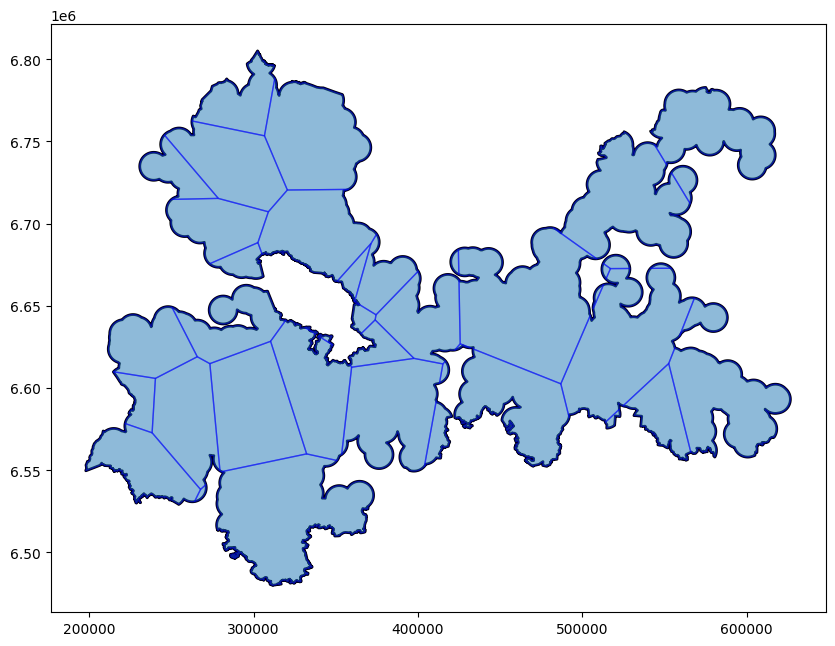

In [22]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union
from geovoronoi import voronoi_regions_from_coords

def get_largest_polygon(geometry):
    # """Возвращает самый большой полигон из MultiPolygon."""
    # if isinstance(geometry, MultiPolygon):
    #     return max(geometry.geoms, key=lambda p: p.area)
    return geometry

def voronoi_polygons_within_boundaries(boundaries_gdf, anchor_towns):
    """Создаёт диаграмму Вороного и расширяет полигоны без выхода за границы."""
    points = np.array([(p.x, p.y) for p in anchor_towns.geometry])
    boundary_polygon = boundaries_gdf.unary_union
    region_polys, region_pts = voronoi_regions_from_coords(points, boundary_polygon)
    
    # Преобразуем в GeoDataFrame
    voronoi_gdf = gpd.GeoDataFrame(geometry=[get_largest_polygon(poly) for poly in region_polys.values()], crs=boundaries_gdf.crs)

    return voronoi_gdf

# Построение полигона Вороного и их расширение
voronoi_gdf = voronoi_polygons_within_boundaries(boundaries_gdf, anchor_towns)

# Визуализация
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
boundaries_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
voronoi_gdf.plot(ax=ax, alpha=0.5, edgecolor="blue")
plt.show()


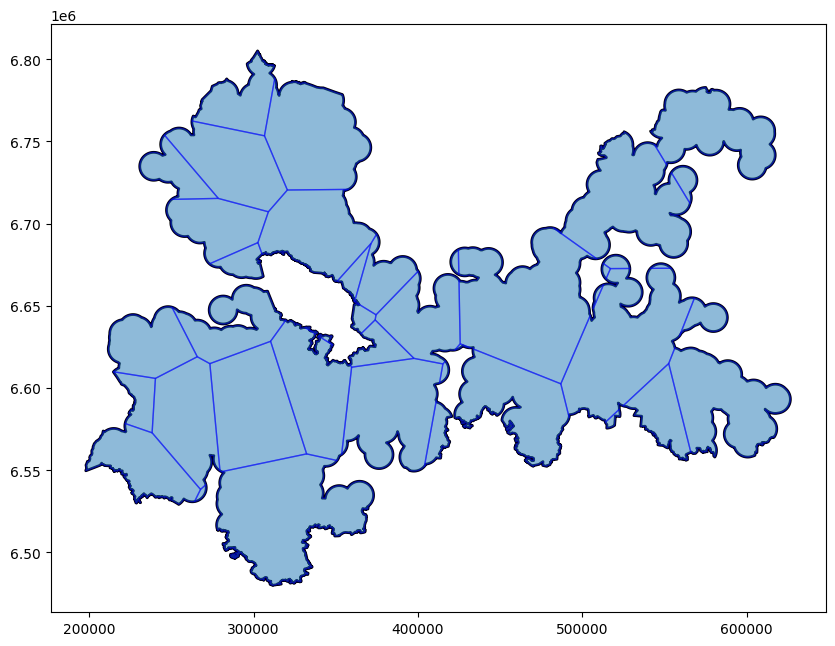

In [27]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union
from geovoronoi import voronoi_regions_from_coords

def split_multipolygons(geometry):
    """Разбивает MultiPolygon на отдельные полигоны."""
    if isinstance(geometry, MultiPolygon):
        return list(geometry.geoms)
    return [geometry]

def voronoi_polygons_within_boundaries(boundaries_gdf, anchor_towns, expansion_step=0.01):
    """Создаёт диаграмму Вороного и расширяет полигоны без выхода за границы."""
    points = np.array([(p.x, p.y) for p in anchor_towns.geometry])
    boundary_polygon = boundaries_gdf.unary_union
    region_polys, region_pts = voronoi_regions_from_coords(points, boundary_polygon)
    
    # Разбиваем MultiPolygon и создаем GeoDataFrame
    polygons = []
    for poly in region_polys.values():
        polygons.extend(split_multipolygons(poly))
    
    voronoi_gdf = gpd.GeoDataFrame(geometry=polygons, crs=boundaries_gdf.crs)
    return voronoi_gdf

# Построение полигона Вороного и их расширение
voronoi_gdf = voronoi_polygons_within_boundaries(boundaries_gdf, anchor_towns)

# Визуализация
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
boundaries_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
voronoi_gdf.plot(ax=ax, alpha=0.5, edgecolor="blue")
plt.show()


In [28]:
voronoi_gdf.explore()

In [9]:


# Визуализация границ
m = voronoi_gdf.explore(color="black")

# Визуализация не опорных городов (тепловая карта по provision)
m = non_anchor_towns.explore(
    m=m,
    column="provision",  # Градиент по 'provision'
    cmap="YlOrRd",  # От жёлтого к красному
    legend=True,  # Включаем легенду
    tooltip=["name", "provision"],  # Всплывающие подсказки
)

# Визуализация опорных городов (зелёным цветом)
m = anchor_towns.explore(
    m=m,
    color="green",  # Фиксированный зелёный цвет
    marker_kwds={"radius": 7},  # Размер маркеров
    tooltip="name",  # Всплывающая подсказка с названием города
)

# Показываем карту
m